In [1]:
import os 
import requests
import matplotlib.pyplot as plt
import json
def emdb_resolution(emdb_id):
    url = f"https://www.ebi.ac.uk/emdb/api/entry/processing/{emdb_id}"

    response = requests.get(url)
    try:
        resolution = response.json()["processing"]["final_reconstruction"]["final_reconstruction_type"]["resolution"]["valueOf_x"]
        return resolution
    except (KeyError, json.JSONDecodeError):

        print(f"Error: Could not retrieve resolution for EMDB ID {emdb_id}")
        return None


In [2]:
emdb_resolution(5778)

'3.275'

In [3]:
# get all EMDB ID used for training, validation, testing and calibration
emdb_locscale_paper_json = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal/emdb_ids_locscale.json"

with open(emdb_locscale_paper_json, "r") as f:
    emdb_ids = json.load(f)

emdb_training_ids = emdb_ids["training"]
emdb_validation_ids = emdb_ids["validation"]
emdb_testing_ids = emdb_ids["testing_and_uncertainty_calibration"]
emdb_additional = emdb_ids["additional_test"]


In [4]:
# plot the distribution of resolution for training, validation and testing sets
training_resolutions = [emdb_resolution(emdb_id) for emdb_id in emdb_training_ids]
validation_resolutions = [emdb_resolution(emdb_id) for emdb_id in emdb_validation_ids]
testing_resolutions = [emdb_resolution(emdb_id) for emdb_id in emdb_testing_ids]
additional_resolutions = [emdb_resolution(emdb_id) for emdb_id in emdb_additional]

# filter out None values
training_resolutions = [float(res) for res in training_resolutions if res is not None]
validation_resolutions = [float(res) for res in validation_resolutions if res is not None]
testing_resolutions = [float(res) for res in testing_resolutions if res is not None]
additional_resolutions = [float(res) for res in additional_resolutions if res is not None]



Error: Could not retrieve resolution for EMDB ID 4401


In [5]:
# run statistical test using permutation test to compare the distributions of resolution between training, validation and testing sets
from scipy.stats import permutation_test
import numpy as np
def statistic(x, y):
    return np.mean(x) - np.mean(y)

training_validation_p_value = permutation_test((training_resolutions, validation_resolutions), statistic)
training_testing_p_value = permutation_test((training_resolutions, testing_resolutions), statistic)
validation_testing_p_value = permutation_test((validation_resolutions, testing_resolutions), statistic)
training_additional_p_value = permutation_test((training_resolutions, additional_resolutions), statistic)
validation_additional_p_value = permutation_test((validation_resolutions, additional_resolutions), statistic)
testing_additional_p_value = permutation_test((testing_resolutions, additional_resolutions), statistic)



In [6]:
p_value_training_validation = training_validation_p_value.pvalue
p_value_training_testing = training_testing_p_value.pvalue
p_value_validation_testing = validation_testing_p_value.pvalue
p_value_training_additional = training_additional_p_value.pvalue
p_value_validation_additional = validation_additional_p_value.pvalue
p_value_testing_additional = testing_additional_p_value.pvalue

print(f"P-value for training vs validation: {p_value_training_validation}")
print(f"P-value for training vs testing: {p_value_training_testing}")
print(f"P-value for validation vs testing: {p_value_validation_testing}")
print(f"P-value for training vs additional: {p_value_training_additional}") 
print(f"P-value for validation vs additional: {p_value_validation_additional}")
print(f"P-value for testing vs additional: {p_value_testing_additional}")


P-value for training vs validation: 0.2156
P-value for training vs testing: 0.8218
P-value for validation vs testing: 0.4658
P-value for training vs additional: 0.3582
P-value for validation vs additional: 0.6116
P-value for testing vs additional: 0.716


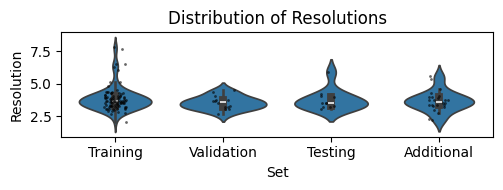

In [7]:
import seaborn as sns
from matplotlib import rcParams
rcParams["pdf.fonttype"] = 42
# Create a DataFrame for plotting
import pandas as pd
data = {
    "Resolution": training_resolutions + validation_resolutions + testing_resolutions + additional_resolutions,
    "Set": ["Training"] * len(training_resolutions) + ["Validation"] * len(validation_resolutions) + ["Testing"] * len(testing_resolutions) + ["Additional"] * len(additional_resolutions)
}
df = pd.DataFrame(data)
# Plot the distribution of resolutions using seaborn
fig, ax = plt.subplots(figsize=(5, 2))
sns.violinplot(x="Set", y="Resolution", data=df, ax=ax)
sns.stripplot(x="Set", y="Resolution", data=df, color="k", alpha=0.6, ax=ax, size=2)
ax.set_title("Distribution of Resolutions")
plt.tight_layout()
save_path = emdb_locscale_paper_json.replace("emdb_ids_locscale.json", "resolution_distribution.pdf")
plt.savefig(save_path, dpi=600)



In [12]:
def get_instrument(emdb_id):
    url = f"https://www.ebi.ac.uk/emdb/api/entry/imaging/{emdb_id}"
    response = requests.get(url)
    try:
        instrument = response.json()["imaging"]["base_microscopy_type"]["microscope"]
        return instrument
    except (KeyError, json.JSONDecodeError):
        print(f"Error: Could not retrieve instrument for EMDB ID {emdb_id}")
        return None

In [13]:
get_instrument(4411)

'FEI TITAN KRIOS'

In [14]:
microscopes_training = [get_instrument(emdb_id) for emdb_id in emdb_training_ids]
microscopes_validation = [get_instrument(emdb_id) for emdb_id in emdb_validation_ids]
microscopes_testing = [get_instrument(emdb_id) for emdb_id in emdb_testing_ids]
microscopes_additional = [get_instrument(emdb_id) for emdb_id in emdb_additional]


Error: Could not retrieve instrument for EMDB ID 4401
Error: Could not retrieve instrument for EMDB ID 13234
Error: Could not retrieve instrument for EMDB ID 19999
Error: Could not retrieve instrument for EMDB ID 17929
Error: Could not retrieve instrument for EMDB ID 15949


In [15]:
# print unique microscopes used in training, validation and testing sets
print(f"Unique microscopes in training set: {set(microscopes_training)}")
print(f"Unique microscopes in validation set: {set(microscopes_validation)}")
print(f"Unique microscopes in testing set: {set(microscopes_testing)}")
print(f"Unique microscopes in additional set: {set(microscopes_additional)}")




Unique microscopes in training set: {'FEI TITAN KRIOS', 'JEOL 3200FSC', 'FEI TECNAI ARCTICA', None, 'TFS KRIOS', 'FEI TALOS ARCTICA', 'FEI POLARA 300', 'FEI TITAN', 'FEI TECNAI F30'}
Unique microscopes in validation set: {'FEI TITAN KRIOS', 'FEI TITAN', 'FEI TALOS ARCTICA', 'FEI POLARA 300'}
Unique microscopes in testing set: {'FEI TITAN KRIOS', 'FEI TALOS ARCTICA', 'FEI POLARA 300'}
Unique microscopes in additional set: {'FEI TITAN KRIOS', None, 'TFS KRIOS', 'FEI TALOS ARCTICA', 'JEOL CRYO ARM 300'}


/tmp/ipykernel_2971/640276292.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


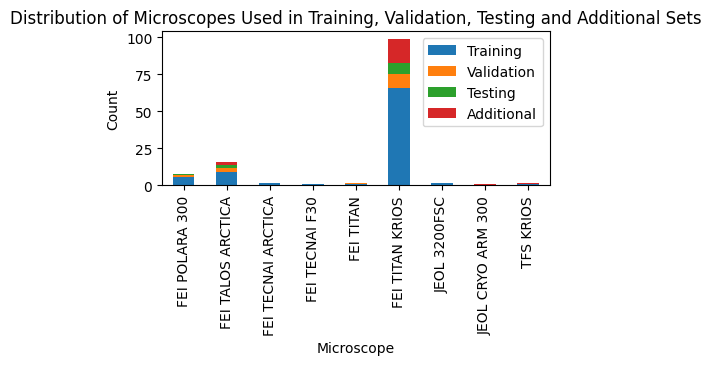

In [16]:
# plot the distribution of microscopes used in training, validation, testing and additional sets as a stacked bar plot
microscope_counts_training = pd.Series(microscopes_training).value_counts()
microscope_counts_validation = pd.Series(microscopes_validation).value_counts()
microscope_counts_testing = pd.Series(microscopes_testing).value_counts()
microscope_counts_additional = pd.Series(microscopes_additional).value_counts()
microscope_counts_df = pd.DataFrame({
    "Training": microscope_counts_training,
    "Validation": microscope_counts_validation,
    "Testing": microscope_counts_testing,
    "Additional": microscope_counts_additional
}).fillna(0)
microscope_counts_df.plot(kind="bar", stacked=True, figsize=(5, 2))
plt.title("Distribution of Microscopes Used in Training, Validation, Testing and Additional Sets")
plt.xlabel("Microscope")
plt.ylabel("Count")
plt.tight_layout()


In [23]:
# plot count versus dataset 
all_microscopes_used_for_training = set(microscopes_training)
all_microscopes_used_for_validation = set(microscopes_validation)
all_microscopes_used_for_testing = set(microscopes_testing)
all_microscopes_used_for_additional = set(microscopes_additional)

unique_microscopes = set(microscopes_training + microscopes_validation + microscopes_testing + microscopes_additional)
microscope_counts = {
    "Training": [microscopes_training.count(microscope) for microscope in unique_microscopes],
    "Validation": [microscopes_validation.count(microscope) for microscope in unique_microscopes],
    "Testing": [microscopes_testing.count(microscope) for microscope in unique_microscopes],
    "Additional": [microscopes_additional.count(microscope) for microscope in unique_microscopes]
}

microscope_countes_percentage_of_total = {
    "Training": [microscopes_training.count(microscope) / len(microscopes_training) * 100 for microscope in unique_microscopes],
    "Validation": [microscopes_validation.count(microscope) / len(microscopes_validation) * 100 for microscope in unique_microscopes],
    "Testing": [microscopes_testing.count(microscope) / len(microscopes_testing) * 100 for microscope in unique_microscopes],
    "Additional": [microscopes_additional.count(microscope) / len(microscopes_additional) * 100 for microscope in unique_microscopes]
}


Text(0, 0.5, 'Percentage')

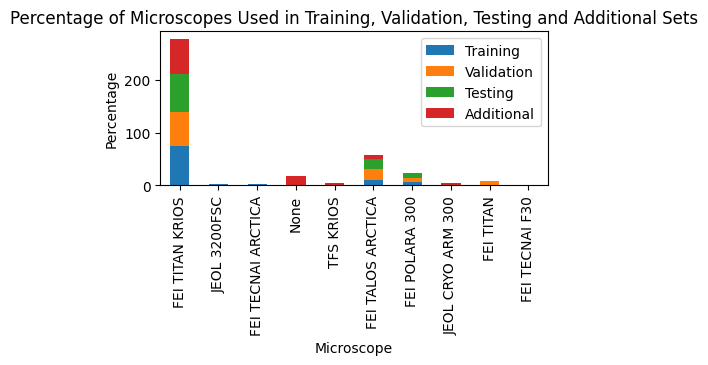

In [26]:
# plot microscope_countes_percentage_of_total as a stacked bar plot
list_of_unique_microscopes_for_indexing = list(unique_microscopes)
microscope_counts_percentage_df = pd.DataFrame(microscope_countes_percentage_of_total, index=list_of_unique_microscopes_for_indexing)
microscope_counts_percentage_df.plot(kind="bar", stacked=True, figsize=(5, 2))
plt.title("Percentage of Microscopes Used in Training, Validation, Testing and Additional Sets")
plt.xlabel("Microscope")
plt.ylabel("Percentage")